In [7]:
# Cell 1 - Imports
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ GPU available: {torch.cuda.is_available()}")
print(f"✅ Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

✅ PyTorch version: 2.11.0+cpu
✅ GPU available: False
✅ Device: CPU


In [8]:
# Cell 2 - Define paths and transforms
BASE_DIR = Path("..").resolve()
SPLITS_DIR = BASE_DIR / "data" / "splits"

# Training transforms - with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and test transforms - no augmentation
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Transforms defined!")
print(f"Splits directory exists: {SPLITS_DIR.exists()}")

✅ Transforms defined!
Splits directory exists: True


In [9]:
# Cell 3 - Load datasets
train_dataset = datasets.ImageFolder(
    root=str(SPLITS_DIR / "train"),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=str(SPLITS_DIR / "val"),
    transform=val_transforms
)

test_dataset = datasets.ImageFolder(
    root=str(SPLITS_DIR / "test"),
    transform=val_transforms
)

# Class names
CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"✅ Datasets loaded!")
print(f"\n📊 Dataset sizes:")
print(f"  Train: {len(train_dataset)} images")
print(f"  Val:   {len(val_dataset)} images")
print(f"  Test:  {len(test_dataset)} images")
print(f"\n🏷️ Number of classes: {NUM_CLASSES}")
print(f"\n📋 Class names:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

✅ Datasets loaded!

📊 Dataset sizes:
  Train: 20302 images
  Val:   4349 images
  Test:  4362 images

🏷️ Number of classes: 20

📋 Class names:
  0: cat_flea_allergy
  1: cat_healthy
  2: cat_ringworm
  3: cat_scabies
  4: dog_demodicosis
  5: dog_dermatitis
  6: dog_fungal_infections
  7: dog_healthy
  8: dog_hypersensitivity
  9: dog_ringworm
  10: human_atopic_dermatitis
  11: human_basal_cell_carcinoma
  12: human_benign_keratosis
  13: human_eczema
  14: human_melanocytic_nevi
  15: human_melanoma
  16: human_psoriasis
  17: human_seborrheic_keratoses
  18: human_tinea_ringworm
  19: human_warts_molluscum


In [10]:
# Cell 4 - Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"✅ DataLoaders created!")
print(f"\n📦 Batch size: {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

✅ DataLoaders created!

📦 Batch size: 32
  Train batches: 635
  Val batches:   136
  Test batches:  137


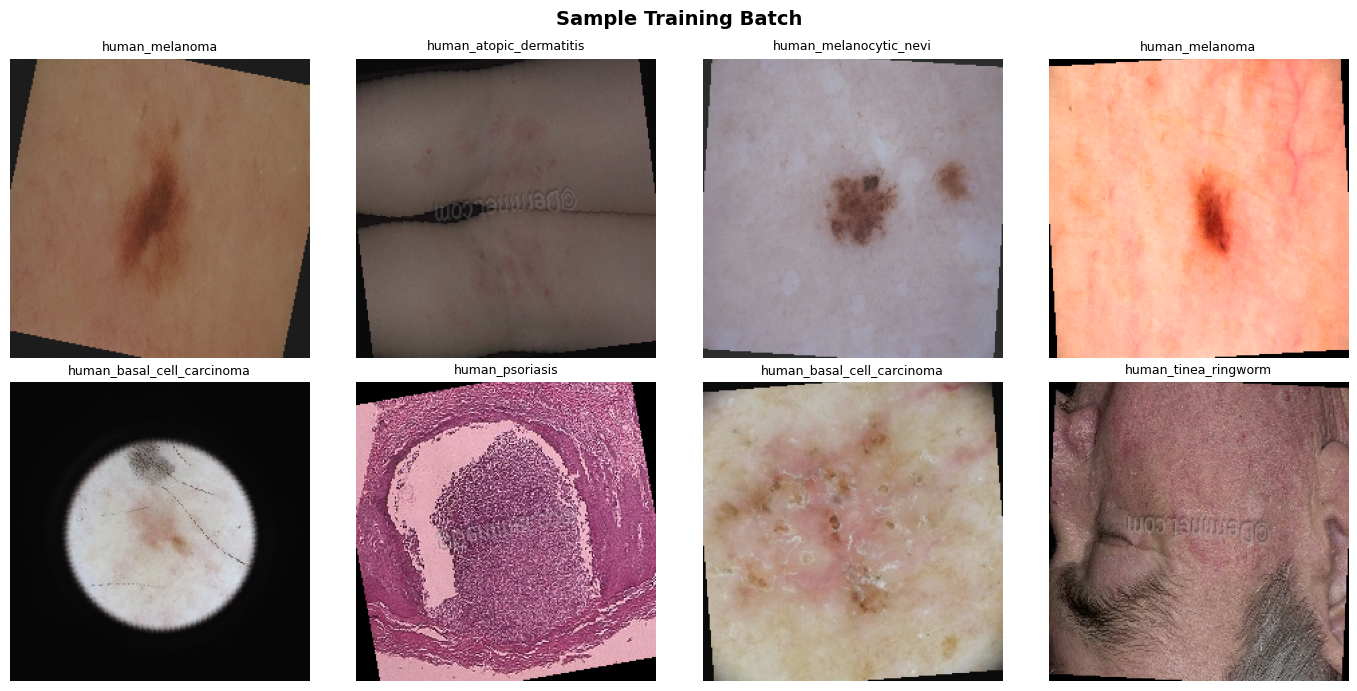

✅ Sample batch displayed!


In [11]:
# Cell 5 - Visualize sample batch
def show_batch(loader, class_names, num_images=8):
    # Get one batch
    images, labels = next(iter(loader))
    
    # Denormalize images for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images = images * std + mean
    images = torch.clamp(images, 0, 1)
    
    # Plot
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()
    
    for i in range(min(num_images, len(images))):
        img = images[i].permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i]], fontsize=9)
        axes[i].axis('off')
    
    plt.suptitle("Sample Training Batch", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("✅ Sample batch displayed!")

show_batch(train_loader, CLASS_NAMES)

In [12]:
# Cell 6 - Save class names and dataset info
import json

dataset_info = {
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "dataset_sizes": {
        "train": len(train_dataset),
        "val":   len(val_dataset),
        "test":  len(test_dataset)
    },
    "batch_size": BATCH_SIZE,
    "image_size": [224, 224]
}

# Save to file
save_path = BASE_DIR / "utils" / "dataset_info.json"
with open(save_path, "w") as f:
    json.dump(dataset_info, f, indent=4)

print("✅ Dataset info saved!")
print(f"📄 Saved to: {save_path}")
print(f"\n📊 Summary:")
print(f"  Classes:     {NUM_CLASSES}")
print(f"  Train:       {len(train_dataset)}")
print(f"  Val:         {len(val_dataset)}")
print(f"  Test:        {len(test_dataset)}")
print(f"  Total:       {len(train_dataset)+len(val_dataset)+len(test_dataset)}")
print("\n🎉 Dataset Loader Notebook Complete!")

✅ Dataset info saved!
📄 Saved to: C:\Users\shruti\Desktop\project\Skin-Disease Predictor\utils\dataset_info.json

📊 Summary:
  Classes:     20
  Train:       20302
  Val:         4349
  Test:        4362
  Total:       29013

🎉 Dataset Loader Notebook Complete!
